# Stochastic Logistic Regression + Adam
Baseline model for 30-day hospital readmission prediction using the Diabetes 130-US Hospitals dataset.

## Imports

In [3]:
import sys
import os
import numpy as np
import pandas as pd
import pickle
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# output directories
PROJECT_ROOT = os.getcwd()
output_dir   = os.path.join(PROJECT_ROOT, 'outputs', 'sto_logreg')
graph_dir    = os.path.join(PROJECT_ROOT, 'graphs', 'sto_logreg')
os.makedirs(output_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

## Data Loading
Load the UCI Diabetes 130-US Hospitals dataset and preprocess.

In [4]:
def load_data():
    print('Loading dataset...')
    raw  = fetch_ucirepo(id=296)
    X    = raw.data.features.copy()
    y    = raw.data.targets.copy()

    y = (y['readmitted'] == '<30').astype(int).values

    # drop columns
    cols_to_drop = [
        'weight',
        'payer_code',
        'medical_specialty',
        'encounter_id',
        'patient_nbr',
        'diag_1',
        'diag_2',       # one hot encoding to fix termination error
        'diag_3',
    ]
    X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

    if 'discharge_disposition_id' in X.columns:
        dead_codes = [11, 13, 14, 19, 20, 21]
        mask = ~X['discharge_disposition_id'].isin(dead_codes)
        X    = X[mask]
        y    = y[mask]

    X = X.replace('?', np.nan)

    missing_frac = X.isnull().mean()
    X = X.drop(columns=missing_frac[missing_frac > 0.4].index)

    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(exclude=[np.number]).columns

    # drop any cat column with more than 20 unique values instead of encoding
    high_cardinality = [c for c in cat_cols if X[c].nunique() > 20]
    X = X.drop(columns=high_cardinality)
    cat_cols = [c for c in cat_cols if c not in high_cardinality]

    X[num_cols] = X[num_cols].fillna(X[num_cols].median())
    X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])
    X = pd.get_dummies(X, columns=list(cat_cols), drop_first=True)

    print(f'Final dataset: {X.shape[0]} rows, {X.shape[1]} features')
    print(f'Positive class (readmitted <30d): {y.mean()*100:.1f}%')

    return X, y


X, y = load_data()

Loading dataset...


/Users/jaydenchen/Downloads/ML/final_proj/Middlebury-ML-Class-Proj/.venv/lib/python3.13/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Final dataset: 99343 rows, 76 features
Positive class (readmitted <30d): 11.4%


## Train/Test Split and Scaling

In [5]:
def split_and_scale(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    feature_cols = list(X_train.columns)

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler, feature_cols


X_train, X_test, y_train, y_test, scaler, feature_cols = split_and_scale(X, y)

n_neg          = (y_train == 0).sum()
n_pos          = (y_train == 1).sum()
pos_weight_val = n_neg / n_pos
print(f'Class weight (pos_weight): {pos_weight_val:.2f}')
print(f'Majority class baseline accuracy: {(1 - y_test.mean())*100:.1f}%')

Class weight (pos_weight): 7.78
Majority class baseline accuracy: 88.6%


## Model and Early Stopping

In [6]:
class StochasticLogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        return self.linear(x)


class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_loss   = float('inf')
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

## Training Loop

In [7]:
def train(X_train, y_train,
          pos_weight_val,
          batch_size=256,
          epochs=50,
          lr=1e-3):

    input_dim = X_train.shape[1]

    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

    loader = DataLoader(
        TensorDataset(X_t, y_t),
        batch_size=batch_size,
        shuffle=True
    )

    model     = StochasticLogisticRegression(input_dim)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_val])
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = []

    print(f'\nTraining: {epochs} epochs | batch size: {batch_size} | lr: {lr}')
    print(f'pos_weight: {pos_weight_val:.2f} | steps per epoch: {len(loader)}')
    print('-' * 50)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        history.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} -- loss: {avg_loss:.4f}')

    return model, history


model, history = train(
    X_train, y_train,
    pos_weight_val = pos_weight_val,
    batch_size     = 256,
    epochs         = 50,
    lr             = 1e-3
)


Training: 50 epochs | batch size: 256 | lr: 0.001
pos_weight: 7.78 | steps per epoch: 311
--------------------------------------------------
  Epoch  10/50 -- loss: 1.1688
  Epoch  20/50 -- loss: 1.1681
  Epoch  30/50 -- loss: 1.1686
  Epoch  40/50 -- loss: 1.1684
  Epoch  50/50 -- loss: 1.1682


## Evaluation

In [8]:
def evaluate(model, X_test, y_test, threshold=0.5):
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32)

    with torch.no_grad():
        probs = torch.sigmoid(model(X_t)).squeeze().numpy()

    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    ppv         = tp / (tp + fp) if (tp + fp) > 0 else 0
    auc         = roc_auc_score(y_test, probs)

    print(f'\n--- Evaluation (threshold = {threshold}) ---')
    print(f'  Sensitivity (recall): {sensitivity:.3f}')
    print(f'  PPV (precision):      {ppv:.3f}')
    print(f'  AUC-ROC:              {auc:.3f}')
    print(f'  Confusion matrix:')
    print(f'    TN={tn:6d}  FP={fp:6d}')
    print(f'    FN={fn:6d}  TP={tp:6d}')

    return probs, {'sensitivity': sensitivity, 'ppv': ppv, 'auc': auc}


probs, metrics = evaluate(model, X_test, y_test, threshold=0.5)


--- Evaluation (threshold = 0.5) ---
  Sensitivity (recall): 0.518
  PPV (precision):      0.177
  AUC-ROC:              0.645
  Confusion matrix:
    TN= 12161  FP=  5445
    FN=  1091  TP=  1172


## Confusion Matrix

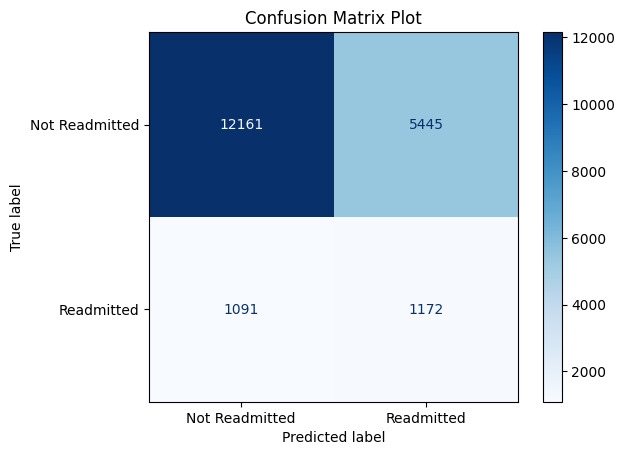

Saved: confusion_matrix.png


In [9]:
preds  = (probs >= 0.5).astype(int)
cm_disp = confusion_matrix(y_test, preds, labels=[0, 1])
disp    = ConfusionMatrixDisplay(confusion_matrix=cm_disp,
                                  display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix Plot')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix.png'), dpi=180)
plt.show()
print('Saved: confusion_matrix.png')

## Training Loss

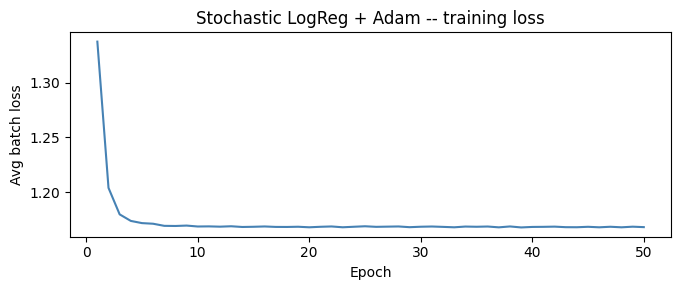

Saved: training_loss.png


In [10]:
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(history) + 1), history,
         color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Avg batch loss')
plt.title('Stochastic LogReg + Adam -- training loss')
plt.tight_layout()
plt.savefig(os.path.join(graph_dir, 'training_loss.png'), dpi=150)
plt.show()
print('Saved: training_loss.png')

## Sensitivity vs PPV Threshold Sweep

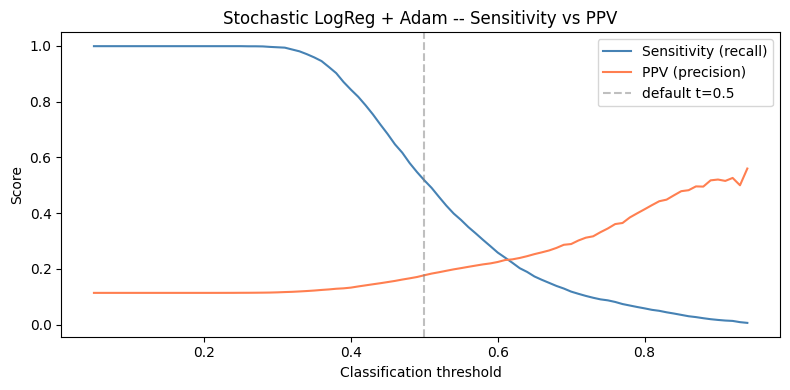

Saved: threshold_sweep.png


In [11]:
thresholds    = np.arange(0.05, 0.95, 0.01)
sensitivities = []
ppvs          = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    if preds.sum() == 0:
        sensitivities.append(0)
        ppvs.append(0)
        continue
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
    sensitivities.append(tp / (tp + fn + 1e-9))
    ppvs.append(tp / (tp + fp + 1e-9))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, sensitivities, label='Sensitivity (recall)', color='steelblue')
plt.plot(thresholds, ppvs,          label='PPV (precision)',      color='coral')
plt.axvline(0.5, linestyle='--', color='gray', alpha=0.5, label='default t=0.5')
plt.xlabel('Classification threshold')
plt.ylabel('Score')
plt.title('Stochastic LogReg + Adam -- Sensitivity vs PPV')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(graph_dir, 'threshold_sweep.png'), dpi=150)
plt.show()
print('Saved: threshold_sweep.png')

## Save Artifacts

In [12]:
with open(os.path.join(output_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print('Saved: scaler.pkl')

with open(os.path.join(output_dir, 'feature_cols.pkl'), 'wb') as f:
    pickle.dump(feature_cols, f)
print(f'Saved: feature_cols.pkl  ({len(feature_cols)} features)')

with open(os.path.join(output_dir, 'model.pkl'), 'wb') as f:
    pickle.dump(model, f)
print('Model saved')

Saved: scaler.pkl
Saved: feature_cols.pkl  (76 features)
Model saved
